# Token Sequence Analysis

Analyses the discrete token sequence produced by the Hilbert VQ-VAE, using the
experimental-condition labels that were **not** seen during codebook learning.

Each instance is one chunk = one token; instances form a time sequence, and
same-condition instances were concatenated into contiguous runs. This notebook:

1. relabels tokens **A, B, C, ...** by frequency (most common first; `AA`..`ZZ` past 26),
2. shows the **token distribution per condition**,
3. draws a **recurrence plot per run**, grouped by condition,
4. reports **RQA metrics** per run and condition,
5. computes **transition matrices** and **information-theoretic measures**, and
6. runs **statistical tests** of condition differences.

Works with amplitude or coherence token files — just change the paths. The codebook
is optional; if given, token descriptors are shown alongside the analyses.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import string
from collections import Counter, defaultdict

sns.set_theme(style="white", context="notebook")

# --- local paths: uncomment these (and comment the three above) to run on your machine ---
TOKENS_NPZ   = "20221005_R_coherence_K24_tokens.npz"
LABELS_NPY   = "/data/1overf/Cleaned_data/20221005_Rlabels.npy"
CODEBOOK_NPZ = "20221005_R_coherence_K24_codebook.npz"


# channel names (for codebook descriptor plots); order must match the model
CHANNEL_NAMES = ['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2',
                 'FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6',
                 'P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
MONTAGE = "standard_1020"

# condition names (label each experimental condition)
# optional pretty names for conditions. Keys may be numeric (matching numeric labels)
# or strings (matching string labels). Any label not in this dict is shown as-is.
# For string label files you can usually leave this empty: {}.
COND_NAME = {1: "Independent", 2: "Leader", 3: "Follower", 4: "Mutual"}
def cname(c):
    # string labels are used as-is; numeric labels are looked up in COND_NAME
    # (falling back to "cond <value>"). COND_NAME may key by int or by str.
    if isinstance(c, str):
        return COND_NAME.get(c, c)
    return COND_NAME.get(c, COND_NAME.get(int(c), f"cond {int(c)}"))

## Load, align, and relabel

One token per instance, aligned 1:1 with the condition labels. Tokens are relabelled
`A, B, C, ...` by their frequency over this recording (most common = `A`).

In [3]:
def code_labels(n):
    out = []
    for i in range(n):
        if i < 26:
            out.append(string.ascii_uppercase[i])
        else:
            j = i - 26
            out.append(string.ascii_uppercase[j // 26] + string.ascii_uppercase[j % 26])
    return out

# labels (experimental condition per instance)
conditions = np.load(LABELS_NPY, allow_pickle=True)
# accept numeric OR string labels; keep native type for all figure labels.
# normalise numeric float labels like 1.0 -> 1 (int) for clean display, leave strings as-is.
if np.issubdtype(conditions.dtype, np.floating):
    if np.allclose(conditions, np.round(conditions)):
        conditions = conditions.astype(int)
elif conditions.dtype.kind in ("U", "S", "O"):
    conditions = conditions.astype(str)

# tokens: one per instance
_tk  = np.load(TOKENS_NPZ, allow_pickle=True)
_tpi = _tk["tokens_per_instance"]
win_per_inst = np.array([len(x) for x in _tpi])
if win_per_inst.max() > 1:
    print(f"NOTE: some instances have >1 window (max {win_per_inst.max()}); "
          f"using the first token of each instance.")
tokens = np.array([int(x[0]) for x in _tpi])

assert len(tokens) == len(conditions), \
    f"{len(tokens)} tokens vs {len(conditions)} labels — must match 1:1"

# the codebook is REQUIRED: token letters are keyed to its usage counts so that
# labels are authoritative and consistent with the codebook-visualisation notebook.
if not CODEBOOK_NPZ:
    raise ValueError("CODEBOOK_NPZ must be set — the codebook is required so that "
                     "token letters are keyed to its usage counts.")
codebook = np.load(CODEBOOK_NPZ, allow_pickle=True)
if "counts" not in codebook.files:
    raise KeyError("codebook .npz has no 'counts' — cannot key token letters to it.")

# relabel tokens A, B, C, ... by codebook usage, most common first
_uniq, _cnts = np.unique(tokens, return_counts=True)
cb_counts = codebook["counts"].astype(int)
used = np.where(cb_counts > 0)[0]
order_ids = used[np.argsort(-cb_counts[used], kind="stable")]

# sanity: every token in this recording must be a used codebook entry
missing = set(int(t) for t in _uniq) - set(int(t) for t in order_ids)
if missing:
    raise ValueError(f"tokens {sorted(missing)} appear in the data but are not used "
                     f"in the codebook — tokens and codebook do not match. "
                     f"Check that TOKENS_NPZ and CODEBOOK_NPZ are from the same model.")
label_basis = "codebook usage counts"

letters   = code_labels(len(order_ids))
id2letter = {int(t): letters[i] for i, t in enumerate(order_ids)}
letter_of = np.array([id2letter[t] for t in tokens])      # per-instance letter
n_codes   = len(order_ids)

# colour per letter (categorical)
_pal = sns.color_palette("husl", n_codes)
letter_color = {letters[i]: _pal[i] for i in range(n_codes)}

# runs: contiguous blocks of the same condition
# run boundaries: where the condition label changes (works for any dtype)
_change = np.where(conditions[1:] != conditions[:-1])[0] + 1
_bd = np.concatenate([[0], _change, [len(conditions)]])
# keep each run's condition in its native type (no int() cast)
runs = [(conditions[_bd[i]], int(_bd[i]), int(_bd[i+1])) for i in range(len(_bd)-1)]
conditions_present = sorted(set(conditions.tolist()))

print(f"{len(tokens)} instances, {n_codes} distinct tokens, "
      f"{len(runs)} runs, conditions {conditions_present}")
print("\ntoken  id   count")
for i, t in enumerate(order_ids):
    print(f"  {letters[i]:<4} {int(t):>3}  {int(_cnts[list(_uniq).index(t)]):>5}")

print(f"\ncodebook loaded: descriptor = {str(codebook['descriptor'])}")
print(f"token labels keyed to: {label_basis}")

767 instances, 13 distinct tokens, 12 runs, conditions [1, 2, 3, 4]

token  id   count
  A      0     99
  B      8     92
  C      7     78
  D     11     72
  E      1     67
  F      5     67
  G     13     61
  H     17     59
  I     19     42
  J     21     35
  K      2     34
  L     20     34
  M     15     27

codebook loaded: descriptor = coherence
token labels keyed to: codebook usage counts


## Token distribution per condition

How often each token occurs within each experimental condition.

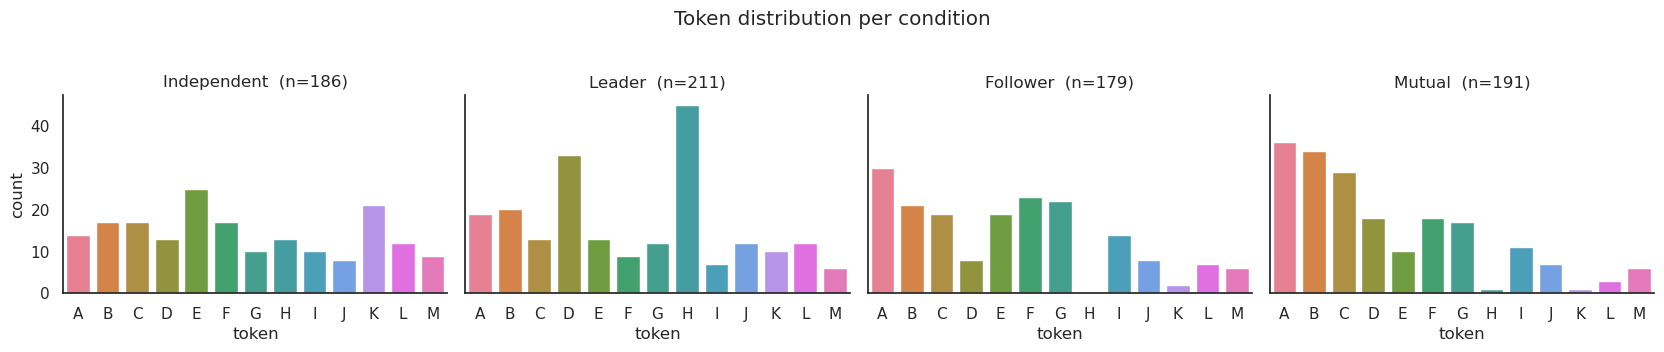

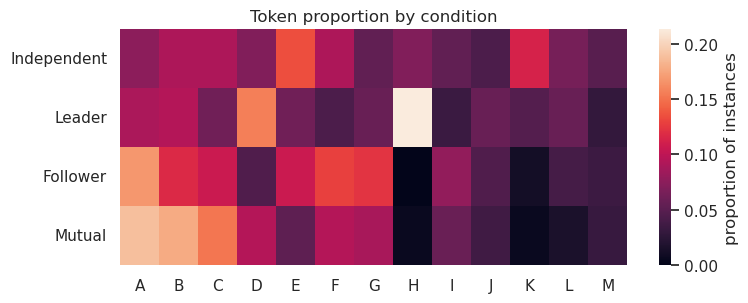

In [4]:
fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.2*len(conditions_present), 3.4), sharey=True)
if len(conditions_present) == 1:
    axes = [axes]
for ax, cond in zip(axes, conditions_present):
    mask = conditions == cond
    cnt  = Counter(letter_of[mask])
    ys   = [cnt.get(L, 0) for L in letters]
    sns.barplot(x=letters, y=ys, hue=letters, palette=letter_color, legend=False, ax=ax)
    ax.set_title(f"{cname(cond)}  (n={int(mask.sum())})")
    ax.set_xlabel("token")
axes[0].set_ylabel("count")
fig.suptitle("Token distribution per condition", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

# also as normalised proportions, side by side
prop = np.zeros((len(conditions_present), n_codes))
for r, cond in enumerate(conditions_present):
    mask = conditions == cond
    cnt = Counter(letter_of[mask])
    tot = mask.sum()
    prop[r] = [cnt.get(L, 0)/tot for L in letters]
fig, ax = plt.subplots(figsize=(max(6, n_codes*0.6), 3.2))
sns.heatmap(prop, ax=ax, cmap="rocket", xticklabels=letters,
            yticklabels=[cname(c) for c in conditions_present],
            cbar_kws={"label": "proportion of instances"})
ax.set_title("Token proportion by condition")
plt.tight_layout()
plt.show()

## Token time series (all trials, grouped by condition)

Each trial is drawn as a horizontal strip: one cell per instance, coloured by its
token. Trials are ordered and grouped by condition, so differences in which tokens
dominate — and in the temporal structure — are visible across brain states. Strips
are left-aligned at their true length (one cell = one instance).

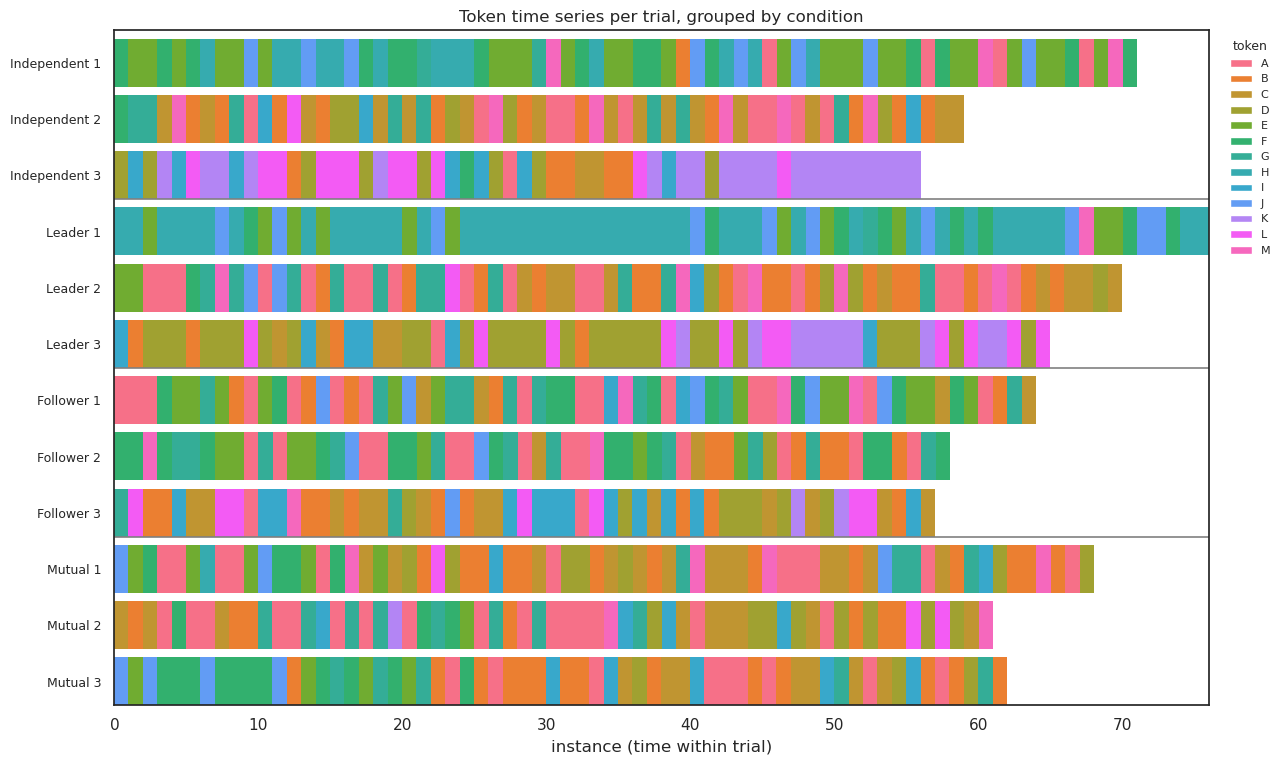

In [5]:
# ensure runs are grouped by condition (also built in the recurrence section)
if "runs_by_cond" not in dir():
    runs_by_cond = defaultdict(list)
    for _i, (_c, _s, _e) in enumerate(runs):
        runs_by_cond[_c].append((_i, _s, _e))

from matplotlib.patches import Patch

# order the 12 trials by condition, then keep their natural order within a condition
ordered = []
for cond in conditions_present:
    for (idx, s, e) in runs_by_cond[cond]:
        ordered.append((cond, idx, s, e))

max_len = max(e - s for _, _, s, e in ordered)
row_h   = 1.0
fig, ax = plt.subplots(figsize=(13, 0.55*len(ordered) + 1.2))

# map each letter to an integer + build a ListedColormap in letter order
from matplotlib.colors import ListedColormap
cmap = ListedColormap([letter_color[L] for L in letters])
letter_to_int = {L: i for i, L in enumerate(letters)}

yticks, ylabels = [], []
trial_counter = defaultdict(int)
for row, (cond, idx, s, e) in enumerate(ordered):
    y = len(ordered) - 1 - row                     # top-to-bottom
    seq_int = np.array([letter_to_int[L] for L in letter_of[s:e]])
    ax.imshow(seq_int[np.newaxis, :], aspect="auto", cmap=cmap,
              vmin=0, vmax=n_codes-1,
              extent=[0, len(seq_int), y, y+0.85], interpolation="nearest")
    trial_counter[cond] += 1
    yticks.append(y + 0.42)
    ylabels.append(f"{cname(cond)} {trial_counter[cond]}")

# faint separators between conditions
boundary = 0
for ci, cond in enumerate(conditions_present[:-1]):
    boundary += len(runs_by_cond[cond])
    yb = len(ordered) - boundary
    ax.axhline(yb, color="0.5", lw=1.2)

ax.set_xlim(0, max_len); ax.set_ylim(0, len(ordered))
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xlabel("instance (time within trial)")
ax.set_title("Token time series per trial, grouped by condition")

# token colour legend
handles = [Patch(facecolor=letter_color[L], label=L) for L in letters]
ax.legend(handles=handles, title="token", bbox_to_anchor=(1.01, 1.0),
          loc="upper left", ncol=1, fontsize=8, title_fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Recurrence plots (per run, grouped by condition)

For each run (a contiguous same-condition sequence), point *(i, j)* is marked when
instance *i* and instance *j* carry the **same token** (categorical recurrence).
The **main diagonal** shows the token sequence itself, coloured by token identity;
off-diagonal points reuse that token's colour, so you can see *which* token recurs
and *when*.

- A **diagonal line** off the main diagonal = a repeated multi-token subsequence (a *motif*).
- A **block/thickening on the diagonal** = a token held over consecutive instances (a *dwell*).

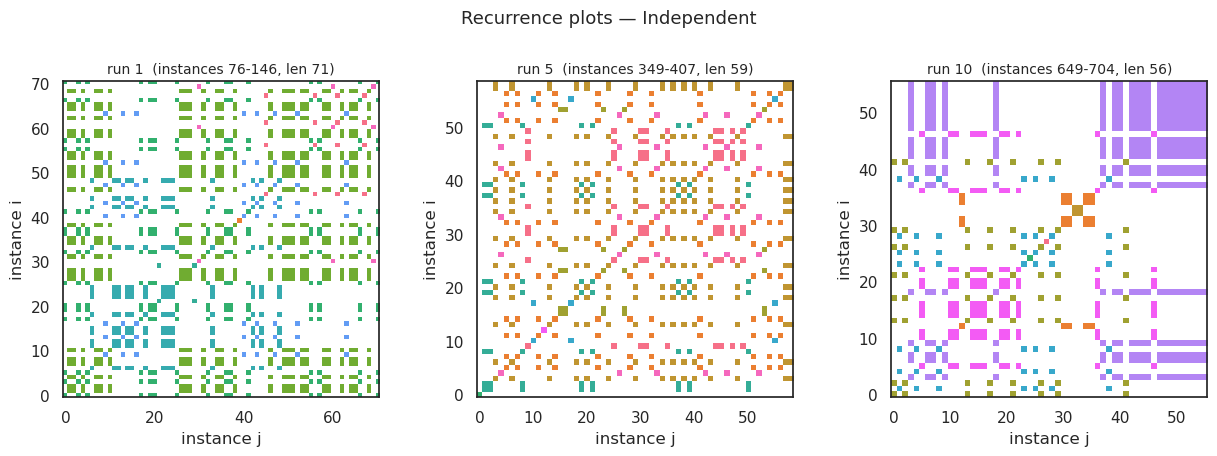

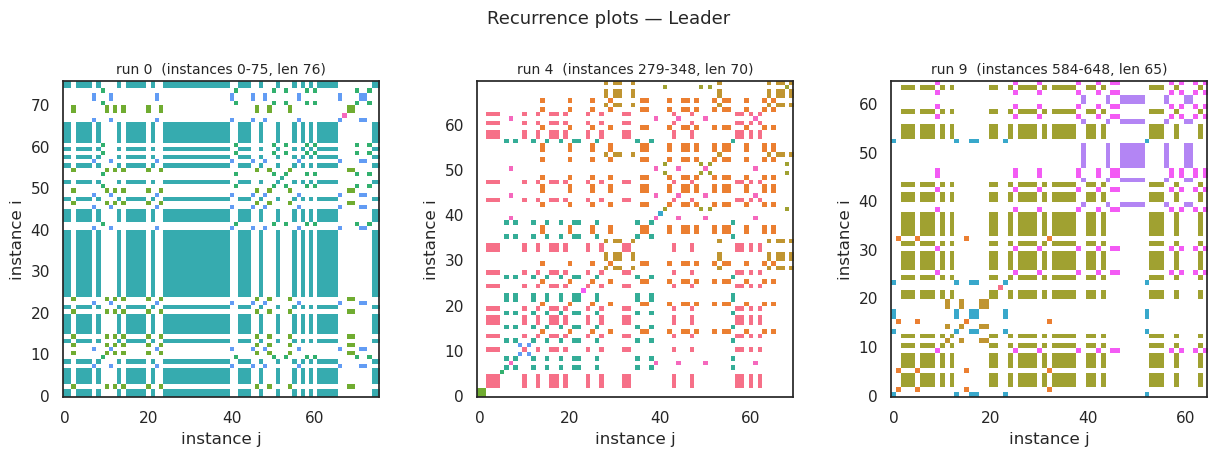

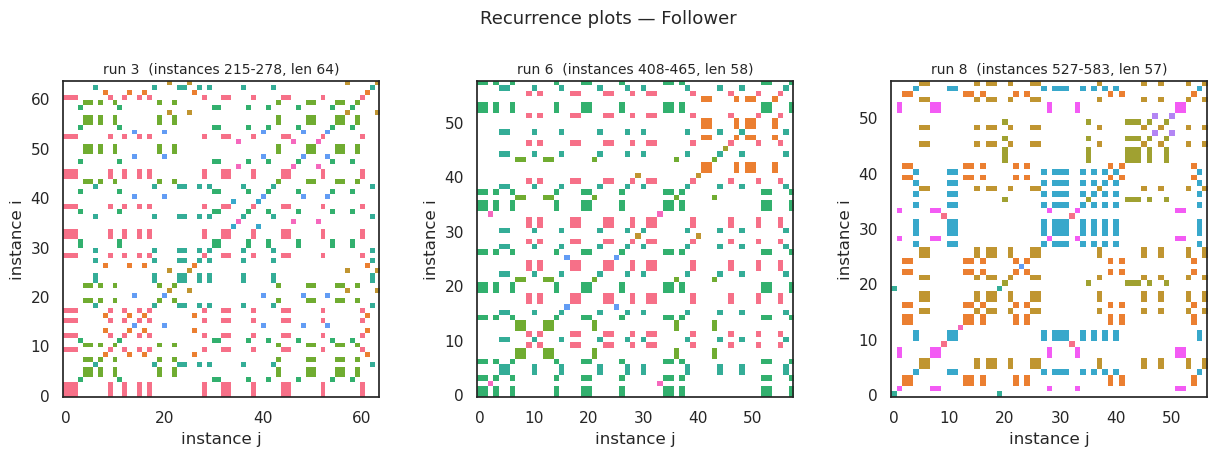

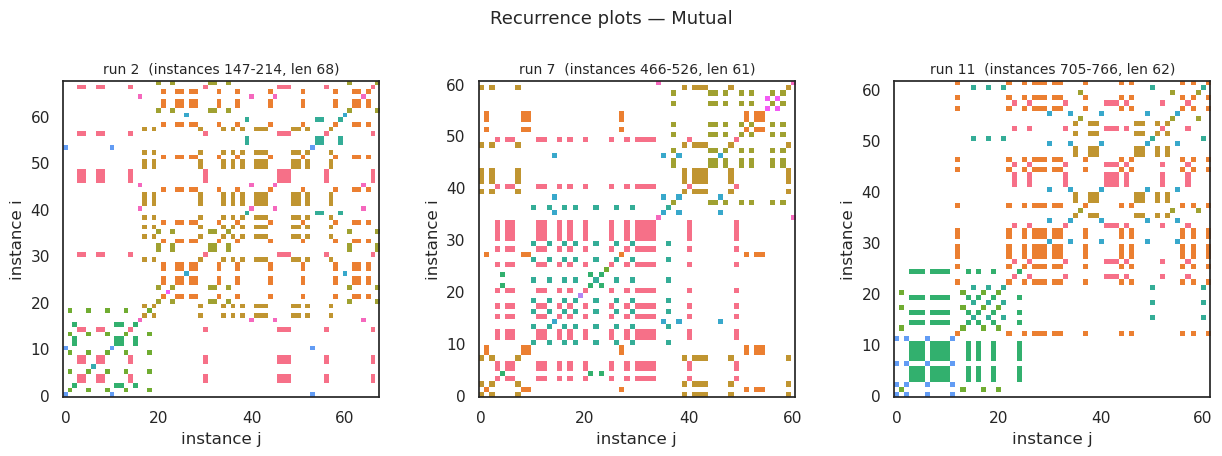

In [6]:
def recurrence_matrix(seq_letters):
    n = len(seq_letters)
    R = np.zeros((n, n), dtype=int)
    for i in range(n):
        R[i] = (seq_letters == seq_letters[i])
    return R

def plot_recurrence_run(ax, seq_letters, title):
    n = len(seq_letters)
    # coloured recurrence: each cell gets the colour of the token when recurrent
    img = np.ones((n, n, 3))
    for i in range(n):
        same = np.where(seq_letters == seq_letters[i])[0]
        col = letter_color[seq_letters[i]]
        for j in same:
            img[i, j] = col
    ax.imshow(img, origin="lower", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("instance j"); ax.set_ylabel("instance i")

# group runs by condition
runs_by_cond = defaultdict(list)
for idx, (cond, s, e) in enumerate(runs):
    runs_by_cond[cond].append((idx, s, e))

for cond in conditions_present:
    group = runs_by_cond[cond]
    fig, axes = plt.subplots(1, len(group), figsize=(4.2*len(group), 4.2), squeeze=False)
    for col, (idx, s, e) in enumerate(group):
        seq = letter_of[s:e]
        plot_recurrence_run(axes[0][col], seq, f"run {idx}  (instances {s}-{e-1}, len {e-s})")
    fig.suptitle(f"Recurrence plots — {cname(cond)}", y=1.04, fontsize=13)
    plt.tight_layout()
    plt.show()

## RQA metrics

Recurrence Quantification Analysis scalars, per run and summarised per condition:

- **RR** (recurrence rate): fraction of recurrent points.
- **DET** (determinism): fraction of recurrent points forming diagonal lines (length ≥ 2) — how motif-driven the dynamics are.
- **L_mean / L_max**: mean and maximum diagonal line length.
- **LAM** (laminarity): fraction of recurrent points forming vertical lines — the dwell analogue.
- **TT** (trapping time): mean vertical line length — mean dwell duration.

In [7]:
def rqa_metrics(seq_letters, l_min=2):
    n = len(seq_letters)
    R = np.zeros((n, n), dtype=bool)
    for i in range(n):
        R[i] = seq_letters == seq_letters[i]
    rr = R.sum() / (n * n)
    # diagonal lines (exclude main diagonal), both directions symmetric so use offset>0
    diag_lengths = []
    for k in range(1, n):
        d = np.diagonal(R, offset=k)
        c = 0
        for v in d:
            if v: c += 1
            elif c: diag_lengths.append(c); c = 0
        if c: diag_lengths.append(c)
    diag_lengths = [L for L in diag_lengths if L >= l_min]
    n_diag_pts = 2 * sum(diag_lengths)             # symmetric
    det = n_diag_pts / R.sum() if R.sum() else 0
    l_mean = np.mean(diag_lengths) if diag_lengths else 0
    l_max  = max(diag_lengths) if diag_lengths else 0
    # vertical lines (laminarity / trapping time)
    vert_lengths = []
    for j in range(n):
        c = 0
        for i in range(n):
            if R[i, j]: c += 1
            elif c: vert_lengths.append(c); c = 0
        if c: vert_lengths.append(c)
    vert_lengths = [L for L in vert_lengths if L >= l_min]
    lam = sum(vert_lengths) / R.sum() if R.sum() else 0
    tt  = np.mean(vert_lengths) if vert_lengths else 0
    return dict(RR=rr, DET=det, L_mean=l_mean, L_max=l_max, LAM=lam, TT=tt)

print(f"{'run':>3} {'condition':>12} {'len':>4}  {'RR':>6} {'DET':>6} {'L_mean':>7} "
      f"{'L_max':>6} {'LAM':>6} {'TT':>6}")
per_cond_metrics = defaultdict(list)
for idx, (cond, s, e) in enumerate(runs):
    m = rqa_metrics(letter_of[s:e])
    per_cond_metrics[cond].append(m)
    print(f"{idx:>3} {cname(cond):>12} {e-s:>4}  {m['RR']:>6.3f} {m['DET']:>6.3f} "
          f"{m['L_mean']:>7.2f} {m['L_max']:>6} {m['LAM']:>6.3f} {m['TT']:>6.2f}")

print("\nPer-condition mean:")
print(f"{'condition':>12}  {'RR':>6} {'DET':>6} {'L_mean':>7} {'L_max':>6} {'LAM':>6} {'TT':>6}")
for cond in conditions_present:
    ms = per_cond_metrics[cond]
    avg = {k: np.mean([mm[k] for mm in ms]) for k in ms[0]}
    print(f"{cname(cond):>12}  {avg['RR']:>6.3f} {avg['DET']:>6.3f} {avg['L_mean']:>7.2f} "
          f"{avg['L_max']:>6.1f} {avg['LAM']:>6.3f} {avg['TT']:>6.2f}")

run    condition  len      RR    DET  L_mean  L_max    LAM     TT
  0       Leader   76   0.400  0.626    3.28     15  0.738   5.08
  1  Independent   71   0.221  0.343    2.30      6  0.540   2.23
  2       Mutual   68   0.129  0.228    2.12      3  0.419   2.21
  3     Follower   64   0.149  0.193    2.03      3  0.349   2.15
  4       Leader   70   0.170  0.281    2.25      4  0.384   2.12
  5  Independent   59   0.162  0.256    2.25      4  0.163   2.00
  6     Follower   58   0.174  0.240    2.19      4  0.452   2.00
  7       Mutual   61   0.148  0.244    2.09      3  0.362   2.52
  8     Follower   57   0.162  0.194    2.12      3  0.432   2.18
  9       Leader   65   0.268  0.492    2.46      5  0.663   3.07
 10  Independent   56   0.225  0.470    2.63      8  0.649   3.55
 11       Mutual   62   0.140  0.260    2.41      4  0.375   2.77

Per-condition mean:
   condition      RR    DET  L_mean  L_max    LAM     TT
 Independent   0.203  0.356    2.40    6.0  0.451   2.59
      L

## Transition matrices per condition

Token-to-token transition probabilities within each condition (transitions are
counted **within runs** only, never across run boundaries). Row = current token,
column = next token; each row is normalised to sum to 1. The diagonal reflects
dwelling (staying on the same token).

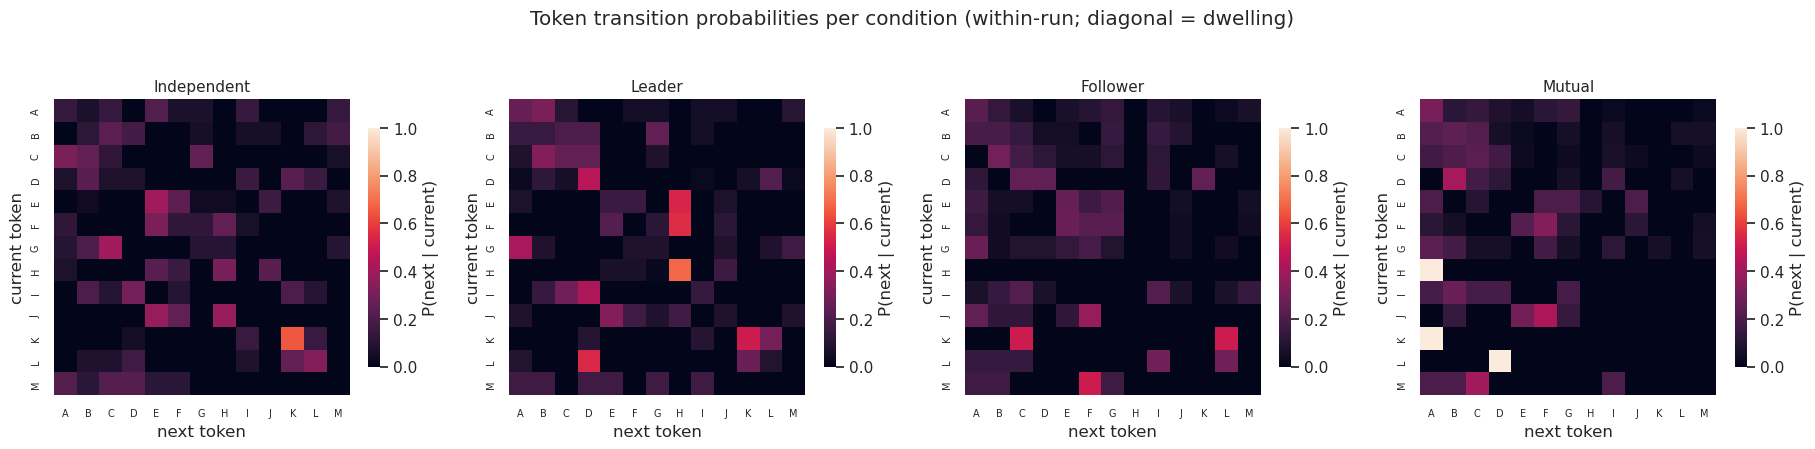

In [8]:
# integer token index per instance, in letter order (A=0, B=1, ...)
tok_idx = np.array([letters.index(L) for L in letter_of])

def transition_counts(cond):
    T = np.zeros((n_codes, n_codes))
    for (idx, s, e) in runs_by_cond[cond]:
        seq = tok_idx[s:e]
        for a, b in zip(seq[:-1], seq[1:]):
            T[a, b] += 1
    return T

fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.6*len(conditions_present), 4.2), squeeze=False)
for col, cond in enumerate(conditions_present):
    T = transition_counts(cond)
    rs = T.sum(1, keepdims=True)
    P = np.divide(T, rs, out=np.zeros_like(T), where=rs > 0)
    ax = axes[0][col]
    sns.heatmap(P, ax=ax, cmap="rocket", vmin=0, vmax=1, square=True,
                xticklabels=letters, yticklabels=letters,
                cbar_kws={"shrink": 0.7, "label": "P(next | current)"})
    ax.set_title(f"{cname(cond)}", fontsize=11)
    ax.set_xlabel("next token"); ax.set_ylabel("current token")
    ax.tick_params(labelsize=7)
fig.suptitle("Token transition probabilities per condition "
             "(within-run; diagonal = dwelling)", y=1.03)
plt.tight_layout(); plt.show()

## Microstate map and transition networks

The tokens live in the model's quantisation space (`codebook_vectors`). We place the
microstates on a 2-D **MDS map** (metric MDS on their Euclidean codebook-space distances,
so nearby points are similar microstates) and draw each condition's transition matrix as a
directed graph on that fixed map. This is a **visualisation** of the transition structure,
not a derived set of graph measures: it shows whether transitions stay local in the
codebook space or jump across it, and where the dominant flows are.

**Edge weight — why log-count, not probability.** An edge $a\to b$ could be weighted by
the transition probability $P(b\mid a)$, but that is misleading for rarely-visited source
states: a token entered once and then moving to $b$ has $P(b\mid a)=1$ and looks maximally
strong on a single observation. Instead edges are weighted by $\log(\text{count}+1)$ —
the log of the number of times the transition actually occurred — which reflects the
traffic along each edge and makes single-observation edges faint rather than bold. Node
size encodes overall token usage; node colour is the token identity.

/home/ramesh/anaconda3/envs/torch126/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/ramesh/anaconda3/envs/torch126/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


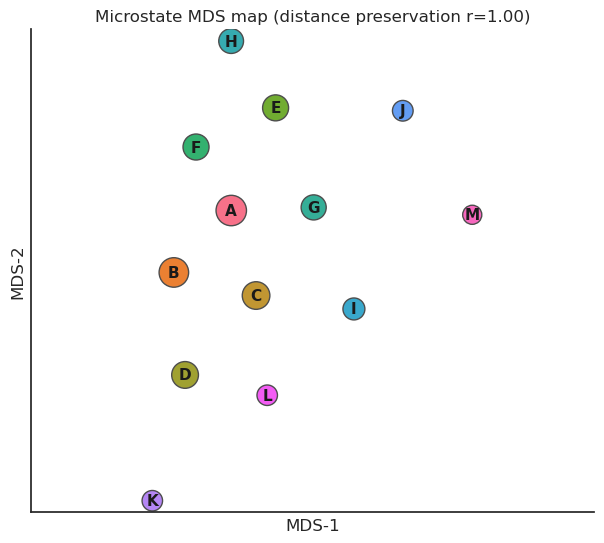

In [9]:
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
import networkx as nx

# ---- MDS coordinates from codebook vectors (tokens used here, letter order) ----
if "codebook_vectors" not in codebook.files:
    raise KeyError("codebook has no 'codebook_vectors' — cannot build the MDS map.")
Vtok = codebook["codebook_vectors"].astype(float)[order_ids]
XY = MDS(n_components=2, dissimilarity="precomputed", random_state=0, n_init=4,
         max_iter=500, normalized_stress=False).fit_transform(squareform(pdist(Vtok,"euclidean")))
pos = {i: (XY[i,0], XY[i,1]) for i in range(n_codes)}       # networkx node positions
_pres = pearsonr(pdist(Vtok,"euclidean"), pdist(XY,"euclidean"))[0]

# overall usage for reference node sizing on the bare map
usage = np.array([np.sum(tok_idx == i) for i in range(n_codes)], float)

# draw the bare MDS map (networkx nodes at MDS positions)
G0 = nx.DiGraph(); G0.add_nodes_from(range(n_codes))
fig, ax = plt.subplots(figsize=(6.2,5.6))
nx.draw_networkx_nodes(G0, pos, ax=ax, node_size=400*(usage/usage.max())+80,
                       node_color=[letter_color[letters[i]] for i in range(n_codes)],
                       edgecolors="0.3")
nx.draw_networkx_labels(G0, pos, labels={i:letters[i] for i in range(n_codes)},
                        ax=ax, font_size=11, font_weight="bold")
ax.set_title(f"Microstate MDS map (distance preservation r={_pres:.2f})")
ax.set_xlabel("MDS-1"); ax.set_ylabel("MDS-2"); ax.set_aspect("equal", adjustable="datalim")
sns.despine(); plt.tight_layout(); plt.show()

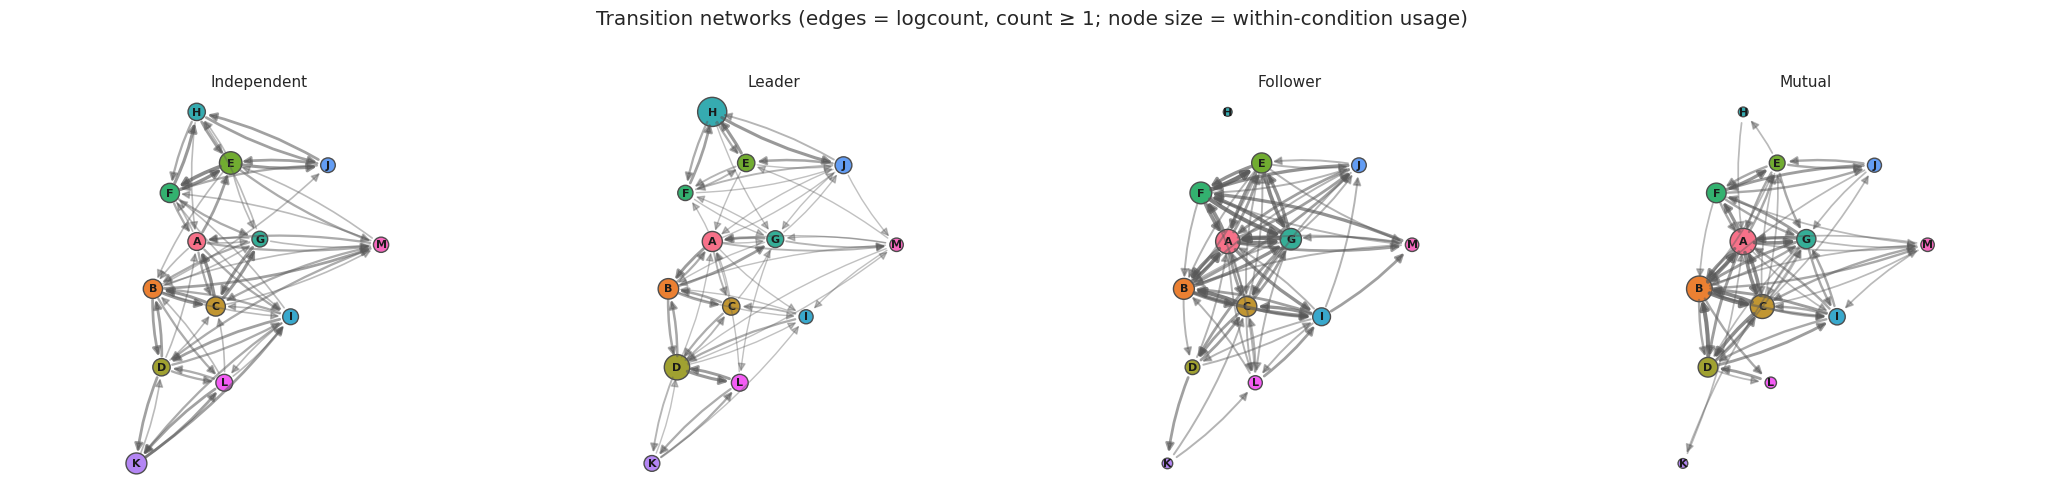

In [10]:
MIN_COUNT   = 1          # keep all observed transitions (log-count weighting makes singletons faint)
EDGE_METRIC = "logcount" # "logcount" (log(count+1)) or "probability"

def build_graph(T):
    """directed graph from a transition-count matrix T (for drawing)."""
    G = nx.DiGraph(); G.add_nodes_from(range(n_codes))
    rs = T.sum(1, keepdims=True)
    for a in range(n_codes):
        for b in range(n_codes):
            c = T[a,b]
            if c < MIN_COUNT: continue
            logw = np.log(c + 1)
            prob = c / rs[a,0] if rs[a,0] > 0 else 0.0
            G.add_edge(a, b, count=c, logcount=logw, probability=prob)
    return G

# node size = token usage WITHIN each condition, on a shared scale, so occupancy
# differences across conditions are visible (a state used heavily in one condition and
# rarely in another changes size across panels)
usage_by_cond = {cond: np.array([np.sum(tok_idx[conditions == cond] == i)
                                 for i in range(n_codes)], float)
                 for cond in conditions_present}
_usage_max = max(u.max() for u in usage_by_cond.values())

fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(5.2*len(conditions_present), 4.8), squeeze=False)
for col, cond in enumerate(conditions_present):
    G = build_graph(transition_counts(cond))
    ax = axes[0][col]
    node_sz = 400*(usage_by_cond[cond]/_usage_max) + 40   # shared scale across panels
    ews = [d["logcount" if EDGE_METRIC=="logcount" else "probability"] for _,_,d in G.edges(data=True)]
    emax = max(ews) if ews else 1
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sz,
                           node_color=[letter_color[letters[i]] for i in range(n_codes)],
                           edgecolors="0.3")
    nx.draw_networkx_labels(G, pos, labels={i:letters[i] for i in range(n_codes)},
                            ax=ax, font_size=8, font_weight="bold")
    for (a,b,d) in G.edges(data=True):
        w = d["logcount"] if EDGE_METRIC=="logcount" else d["probability"]
        ax.annotate("", xy=pos[b], xytext=pos[a],
                    arrowprops=dict(arrowstyle="-|>", color="0.35",
                                    lw=0.4+3.0*(w/emax), alpha=0.25+0.6*(w/emax),
                                    shrinkA=8, shrinkB=8, connectionstyle="arc3,rad=0.08"))
    ax.set_title(cname(cond), fontsize=11); ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
fig.suptitle(f"Transition networks (edges = {EDGE_METRIC}, count ≥ {MIN_COUNT}; node size = within-condition usage)", y=1.02)
sns.despine(left=True, bottom=True); plt.tight_layout(); plt.show()

## Per-run network measures (shortest path length and betweenness)

Following the transition-network approach of Pinto et al., we compute two topological
measures **per run** and normalise each to the session average (the "relative" scale),
so runs are comparable. Each run's transition network uses an information cost
$-\ln P(b\mid a)$ on each edge, so that costs are additive along a path and the
**shortest path is the most probable route** between two states:

- **Average shortest path length** — the mean cost (summed $-\ln P$) of the most
  probable route between reachable state pairs; longer means probability flow is spread
  over more states (less efficient transit).
- **Average betweenness centrality** — how often states sit on these most-probable paths;
  higher means a more centralised flow through a core of states.

Each measure is divided by the session mean across runs, giving a relative value around
$1$. These are reported **descriptively only**: this single session has just a few runs
per condition, far fewer than needed for the trial-level bootstrap contrast used in the
original study, so no inferential test across conditions is performed here. On a
multi-session dataset the same per-run measures would feed that contrast.

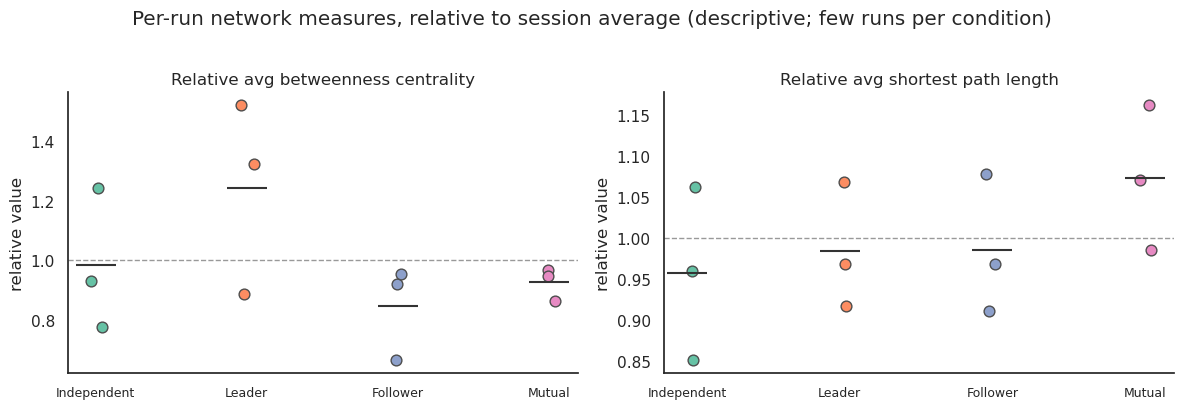

     condition  rel_betweenness  rel_path_length  n_runs
   Independent            0.983            0.957       3
        Leader            1.244            0.984       3
      Follower            0.846            0.986       3
        Mutual            0.926            1.073       3


In [11]:
import networkx as nx
_cond_colors = {c: col for c, col in zip(conditions_present, sns.color_palette("Set2", len(conditions_present)))}

def run_network_measures(s, e):
    """per-run avg betweenness and avg shortest path length, -ln(P) edge costs."""
    seq = tok_idx[s:e]
    T = {}
    for a, b in zip(seq[:-1], seq[1:]): T[(a,b)] = T.get((a,b), 0) + 1
    out = {}
    for (a,b), c in T.items(): out[a] = out.get(a, 0) + c
    G = nx.DiGraph()
    for (a,b), c in T.items():
        p = c / out[a]
        G.add_edge(a, b, cost=-np.log(p))
    if G.number_of_edges() == 0: return np.nan, np.nan
    avg_btw = np.mean(list(nx.betweenness_centrality(G, weight="cost").values()))
    lengths = [d for src, dist in nx.all_pairs_dijkstra_path_length(G, weight="cost")
               for dst, d in dist.items() if src != dst]
    avg_spl = np.mean(lengths) if lengths else np.nan
    return avg_btw, avg_spl

# compute per run, then normalise to session average
run_cond, run_btw, run_spl = [], [], []
for (rc, s, e) in runs:
    ab, asp = run_network_measures(s, e)
    run_cond.append(cname(rc)); run_btw.append(ab); run_spl.append(asp)
run_cond = np.array(run_cond, dtype=object); run_btw = np.array(run_btw); run_spl = np.array(run_spl)
rel_btw = run_btw / np.nanmean(run_btw)
rel_spl = run_spl / np.nanmean(run_spl)

# plot: per-run points by condition, both measures
cond_names = [cname(c) for c in conditions_present]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, ttl in [(axes[0], rel_btw, "Relative avg betweenness centrality"),
                      (axes[1], rel_spl, "Relative avg shortest path length")]:
    for j, cn in enumerate(cond_names):
        m = run_cond == cn
        ax.scatter(np.full(m.sum(), j) + np.random.uniform(-0.05,0.05,m.sum()),
                   vals[m], s=60, color=_cond_colors[conditions_present[j]], edgecolor="0.3", zorder=3)
        ax.scatter([j], [np.nanmean(vals[m])], marker="_", s=800, color="0.2", zorder=4)
    ax.axhline(1.0, color="0.6", ls="--", lw=1)
    ax.set_xticks(range(len(cond_names))); ax.set_xticklabels(cond_names, fontsize=9)
    ax.set_ylabel("relative value"); ax.set_title(ttl)
fig.suptitle("Per-run network measures, relative to session average (descriptive; few runs per condition)", y=1.02)
sns.despine(); plt.tight_layout(); plt.show()

# descriptive table
print(f"{'condition':>14} {'rel_betweenness':>16} {'rel_path_length':>16} {'n_runs':>7}")
for cn, cond in zip(cond_names, conditions_present):
    m = run_cond == cn
    print(f"{cn:>14} {np.nanmean(rel_btw[m]):>16.3f} {np.nanmean(rel_spl[m]):>16.3f} {int(m.sum()):>7}")

## Information-theoretic measures

- **Entropy** $H$ of the token distribution per condition (bits): how spread out the
  microstate usage is. Low $H$ = a focused state using few tokens; high $H$ = diffuse.
  The maximum is $\log_2 K$.
- **Mutual information** $I(\text{token};\text{condition})$: how much knowing the
  condition tells you about the token — a single number for how distinct the
  conditions' token usage is (0 = identical distributions).
- **Entropy rate** $h$ per condition: the uncertainty of the *next* token given the
  current one (from the transition matrix) — the predictability of the sequence, which
  can differ across conditions even when the marginal distributions are similar.
- **Jensen–Shannon divergence** of each condition's distribution from the overall
  distribution: how far each brain state departs from baseline (0 = identical).

Token-distribution entropy  (max log2 K = 3.70 bits)
   Independent: H = 3.624 bits
        Leader: H = 3.442 bits
      Follower: H = 3.341 bits
        Mutual: H = 3.228 bits
  overall     : H = 3.595 bits

I(token; condition) = 0.1856 bits (5.163% of H(token))

Entropy rate  h (bits/step; lower = more predictable sequence)
   Independent: h = 2.304
        Leader: h = 2.054
      Follower: h = 2.697
        Mutual: h = 2.567

Jensen-Shannon divergence from overall distribution
   Independent: JS = 0.0269
        Leader: JS = 0.0488
      Follower: JS = 0.0629
        Mutual: JS = 0.0606


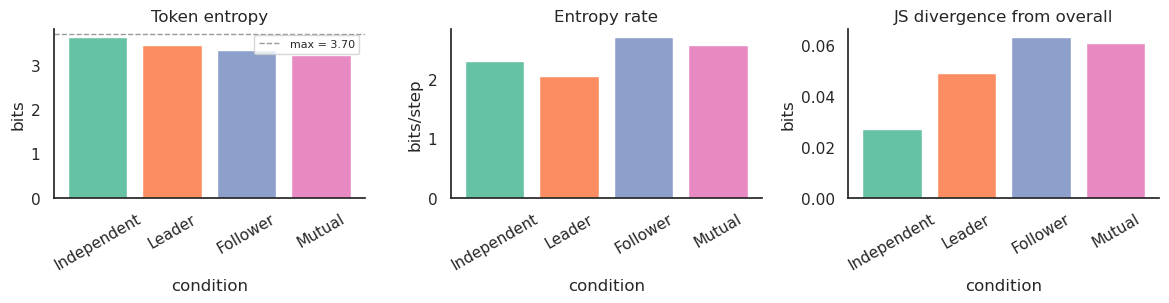

In [12]:
def _entropy(p):
    p = np.asarray(p, float); p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def _dist(mask):
    c = np.bincount(tok_idx[mask], minlength=n_codes).astype(float)
    return c / c.sum() if c.sum() > 0 else c

overall_dist = _dist(np.ones(len(tok_idx), bool))
H_max = np.log2(n_codes)

# entropy per condition
print(f"Token-distribution entropy  (max log2 K = {H_max:.2f} bits)")
for cond in conditions_present:
    print(f"  {cname(cond):>12}: H = {_entropy(_dist(conditions == cond)):.3f} bits")
print(f"  overall     : H = {_entropy(overall_dist):.3f} bits")

# mutual information I(token; condition)
def mutual_information(cond_arr):
    N = len(tok_idx)
    ov = np.bincount(tok_idx, minlength=n_codes) / N
    mi = 0.0
    for cond in conditions_present:
        m = cond_arr == cond
        pc = m.mean()
        pt = _dist(m)
        for i in range(n_codes):
            if pt[i] > 0 and ov[i] > 0:
                mi += pc * pt[i] * np.log2(pt[i] / ov[i])
    return mi

MI = mutual_information(conditions)
print(f"\nI(token; condition) = {MI:.4f} bits "
      f"({MI/_entropy(overall_dist):.3%} of H(token))")

# entropy rate per condition (from within-run transition matrix)
def entropy_rate(cond):
    T = transition_counts(cond)
    rs = T.sum(1)
    if rs.sum() == 0: return 0.0
    pi = rs / rs.sum()
    return float(sum(pi[i] * _entropy(T[i]/rs[i]) for i in range(n_codes) if rs[i] > 0))

print("\nEntropy rate  h (bits/step; lower = more predictable sequence)")
for cond in conditions_present:
    print(f"  {cname(cond):>12}: h = {entropy_rate(cond):.3f}")

# Jensen-Shannon divergence vs overall
def _kl(p, q):
    m = (p > 0) & (q > 0); return float(np.sum(p[m]*np.log2(p[m]/q[m])))
def _js(p, q):
    mid = 0.5*(p+q); return 0.5*_kl(p, mid) + 0.5*_kl(q, mid)

print("\nJensen-Shannon divergence from overall distribution")
for cond in conditions_present:
    print(f"  {cname(cond):>12}: JS = {_js(_dist(conditions == cond), overall_dist):.4f}")

# small summary bar charts: entropy and JS per condition
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
cpal = sns.color_palette("Set2", len(conditions_present))
labels_c = [cname(c) for c in conditions_present]
ax[0].bar(labels_c, [_entropy(_dist(conditions==c)) for c in conditions_present], color=cpal)
ax[0].axhline(H_max, ls="--", c="0.6", lw=1, label=f"max = {H_max:.2f}")
ax[0].set_title("Token entropy"); ax[0].set_ylabel("bits"); ax[0].legend(fontsize=8)
ax[1].bar(labels_c, [entropy_rate(c) for c in conditions_present], color=cpal)
ax[1].set_title("Entropy rate"); ax[1].set_ylabel("bits/step")
ax[2].bar(labels_c, [_js(_dist(conditions==c), overall_dist) for c in conditions_present], color=cpal)
ax[2].set_title("JS divergence from overall"); ax[2].set_ylabel("bits")
for a in ax:
    a.set_xlabel("condition")
    a.tick_params(axis="x", labelrotation=30)
sns.despine(); plt.tight_layout(); plt.show()

## Statistical tests of condition differences

**Design note.** The instances are treated as the population: the question is
whether the conditions use tokens differently *within this recording*. The 3 runs
per condition are counterbalancing to control order effects, not independent
replicates, so they are **not** used as the unit of analysis. The only statistical
nuisance is then the within-sequence autocorrelation (consecutive instances are
correlated — that is the dwell/motif structure), which reduces the effective sample
size. We measure that autocorrelation, then test with two methods that account for
it:

1. an **effective-N chi-square** on the token x condition table (the naive chi-square
   scaled by the measured effective sample size), and
2. a **block permutation** of the condition labels (shuffling contiguous blocks
   preserves local autocorrelation while breaking the token-condition association) —
   a distribution-free confirmation that needs no effective-N assumption.

Within-sequence autocorrelation (the nuisance being corrected for):
  P(token repeats next) = 0.233  vs 0.088 if independent (2.65x)
  mean lag-1 autocorrelation r1 = 0.156  ->  N_eff ~ 559 of 767

Chi-square (token x condition):
  naive         chi2 = 190.4, dof = 36, p = 6.58e-23
  effective-N   chi2 = 138.9 (scaled x0.73), p = 5.17e-14



Block-permutation test for I(token; condition)  (block size 10):
  observed MI = 0.1856 bits, null mean = 0.0791, p = 0.0008


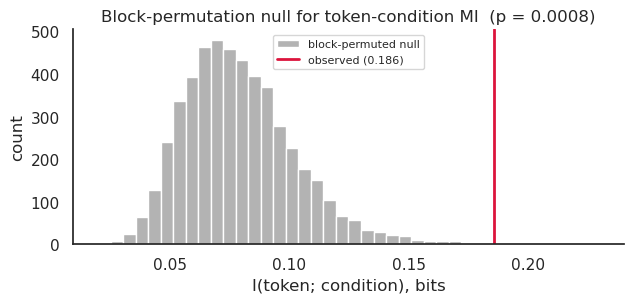


Interpretation: both the effective-N chi-square and the block permutation test whether
the conditions differ in token usage within this recording, accounting for autocorrelation.


In [13]:
from scipy.stats import chi2_contingency, chi2 as chi2dist

# ── 1. measure the within-sequence autocorrelation we must correct for ──
# (a) how much more often a token repeats than under independence
same = tot = 0
for (idx, s, e) in runs:
    seq = tok_idx[s:e]
    same += int(np.sum(seq[:-1] == seq[1:])); tot += len(seq) - 1
p_repeat = same / tot
p_marg   = np.bincount(tok_idx, minlength=n_codes) / len(tok_idx)
exp_repeat = float(np.sum(p_marg**2))
# (b) lag-1 autocorrelation averaged over token indicators -> effective-N factor
r1_num = r1_den = 0.0
for i in range(n_codes):
    x = (tok_idx == i).astype(float); xm = x.mean()
    for (idx, s, e) in runs:
        xs = x[s:e] - xm
        r1_num += np.sum(xs[:-1]*xs[1:]); r1_den += np.sum(xs*xs)
r1 = r1_num / r1_den
neff_factor = (1 - r1) / (1 + r1)
N = len(tok_idx); N_eff = N * neff_factor

print("Within-sequence autocorrelation (the nuisance being corrected for):")
print(f"  P(token repeats next) = {p_repeat:.3f}  vs {exp_repeat:.3f} if independent "
      f"({p_repeat/exp_repeat:.2f}x)")
print(f"  mean lag-1 autocorrelation r1 = {r1:.3f}  ->  N_eff ~ {N_eff:.0f} of {N}")

# ── 2. effective-N chi-square ──
ct = np.zeros((len(conditions_present), n_codes))
for r, cond in enumerate(conditions_present):
    ct[r] = np.bincount(tok_idx[conditions == cond], minlength=n_codes)
chi2, p_naive, dof, _ = chi2_contingency(ct)
p_eff = float(chi2dist.sf(chi2 * neff_factor, dof))
print(f"\nChi-square (token x condition):")
print(f"  naive         chi2 = {chi2:.1f}, dof = {dof}, p = {p_naive:.2e}")
print(f"  effective-N   chi2 = {chi2*neff_factor:.1f} (scaled x{neff_factor:.2f}), "
      f"p = {p_eff:.2e}")

# ── 3. block-permutation test on I(token; condition) ──
def block_perm_labels(arr, bs, rng):
    n = len(arr); nb = int(np.ceil(n / bs))
    blocks = [arr[i*bs:(i+1)*bs] for i in range(nb)]
    return np.concatenate([blocks[i] for i in rng.permutation(nb)])[:n]

BLOCK = 10                                  # ~ a few mean dwell lengths
rng = np.random.default_rng(0); N_PERM = 5000
obs_mi = mutual_information(conditions)
perm_mi = np.array([mutual_information(block_perm_labels(conditions, BLOCK, rng))
                    for _ in range(N_PERM)])
p_block = (np.sum(perm_mi >= obs_mi) + 1) / (N_PERM + 1)
print(f"\nBlock-permutation test for I(token; condition)  (block size {BLOCK}):")
print(f"  observed MI = {obs_mi:.4f} bits, null mean = {perm_mi.mean():.4f}, "
      f"p = {p_block:.4f}")

# visualise the block-permutation null vs observed
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(perm_mi, bins=40, color="0.7", label="block-permuted null")
ax.axvline(obs_mi, color="crimson", lw=2, label=f"observed ({obs_mi:.3f})")
ax.set_xlabel("I(token; condition), bits"); ax.set_ylabel("count")
ax.set_title(f"Block-permutation null for token-condition MI  (p = {p_block:.4f})")
ax.legend(fontsize=8); sns.despine(); plt.tight_layout(); plt.show()

print("\nInterpretation: both the effective-N chi-square and the block permutation "
      "test whether\nthe conditions differ in token usage within this recording, "
      "accounting for autocorrelation.")

## Significance tests for the information-theoretic measures

Each of entropy, entropy rate, and JS-divergence-from-overall is tested with the same
**block-permutation** null used above (contiguous label blocks shuffled, preserving
within-sequence autocorrelation), so results are consistent and account for the
temporal dependence.

- **Omnibus**: does the measure differ *across* conditions at all? Statistic = the
  spread (max − min) of the per-condition values; null = block-permuted spreads.
- **Per-condition**: does a given condition's value stand out from what block
  permutation produces? For entropy and entropy rate this is two-sided (a condition
  may be unusually high or low); for JS-from-overall it is one-sided (departure is
  always ≥ 0).

In [14]:
def _dist_of(mask):
    c = np.bincount(tok_idx[mask], minlength=n_codes).astype(float)
    return c / c.sum() if c.sum() > 0 else c

def _runs_of(cond_arr):
    ch = np.where(cond_arr[1:] != cond_arr[:-1])[0] + 1
    bd = np.concatenate([[0], ch, [len(cond_arr)]])
    return [(cond_arr[bd[i]], int(bd[i]), int(bd[i+1])) for i in range(len(bd)-1)]

# per-condition measures as functions of an arbitrary label array
def _cond_entropy(ca, cc):
    return _entropy(_dist_of(ca == cc))

def _cond_js(ca, cc):
    ov = np.bincount(tok_idx, minlength=n_codes) / len(tok_idx)
    return _js(_dist_of(ca == cc), ov)

def _cond_entropy_rate(ca, cc):
    T = np.zeros((n_codes, n_codes))
    for c, s, e in _runs_of(ca):
        if c != cc: continue
        seq = tok_idx[s:e]
        for a, b in zip(seq[:-1], seq[1:]): T[a, b] += 1
    rs = T.sum(1)
    if rs.sum() == 0: return 0.0
    pi = rs / rs.sum()
    return float(sum(pi[i]*_entropy(T[i]/rs[i]) for i in range(n_codes) if rs[i] > 0))

MEASURES = {"entropy": _cond_entropy,
            "entropy_rate": _cond_entropy_rate,
            "JS_from_overall": _cond_js}
ONE_SIDED = {"entropy": False, "entropy_rate": False, "JS_from_overall": True}

# observed per-condition values
obs = {name: {cc: fn(conditions, cc) for cc in conditions_present}
       for name, fn in MEASURES.items()}

# block-permutation null
rng = np.random.default_rng(0)
N_PERM_IT = 3000; BLOCK_IT = 10
null_vals   = {name: {cc: [] for cc in conditions_present} for name in MEASURES}
null_spread = {name: [] for name in MEASURES}
for _ in range(N_PERM_IT):
    ca = block_perm_labels(conditions, BLOCK_IT, rng)
    for name, fn in MEASURES.items():
        vals = {cc: fn(ca, cc) for cc in conditions_present}
        for cc in conditions_present:
            null_vals[name][cc].append(vals[cc])
        null_spread[name].append(max(vals.values()) - min(vals.values()))

def _p_geq(o, null):
    null = np.asarray(null); return (np.sum(null >= o) + 1) / (len(null) + 1)
def _p_two(o, null):
    null = np.asarray(null); c = null.mean()
    return (np.sum(np.abs(null - c) >= abs(o - c)) + 1) / (len(null) + 1)

# omnibus
print("Omnibus (spread across conditions vs block-permuted null):")
for name in MEASURES:
    o = max(obs[name].values()) - min(obs[name].values())
    print(f"  {name:<16} spread = {o:.4f}   p = {_p_geq(o, null_spread[name]):.4f}")

# per-condition
print("\nPer-condition p-values:")
print(f"{'condition':>12}   {'entropy':>18}   {'entropy_rate':>18}   {'JS_from_overall':>18}")
for cc in conditions_present:
    cells = []
    for name in MEASURES:
        o = obs[name][cc]; nl = null_vals[name][cc]
        p = _p_geq(o, nl) if ONE_SIDED[name] else _p_two(o, nl)
        cells.append(f"{o:.3f} (p={p:.3f})")
    print(f"{cname(cc):>12}   {cells[0]:>18}   {cells[1]:>18}   {cells[2]:>18}")

Omnibus (spread across conditions vs block-permuted null):
  entropy          spread = 0.3957   p = 0.0017
  entropy_rate     spread = 0.6424   p = 0.0017
  JS_from_overall  spread = 0.0360   p = 0.1083

Per-condition p-values:
   condition              entropy         entropy_rate      JS_from_overall
 Independent      3.624 (p=0.085)      2.304 (p=0.376)      0.027 (p=0.242)
      Leader      3.442 (p=0.165)      2.054 (p=0.000)      0.049 (p=0.016)
    Follower      3.341 (p=0.023)      2.697 (p=0.007)      0.063 (p=0.009)
      Mutual      3.228 (p=0.001)      2.567 (p=0.200)      0.061 (p=0.007)


### Observed values against their permutation nulls

Each panel shows, per condition, the observed measure (point) over the block-permuted
null distribution (violin). Points lying outside the bulk of their violin are the
conditions that differ significantly.

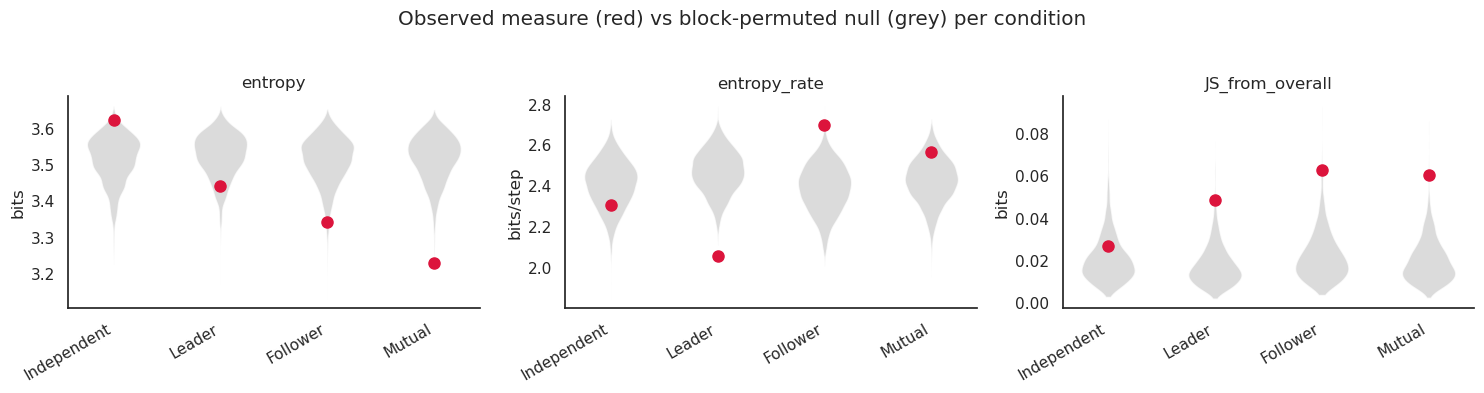

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, name in zip(axes, MEASURES):
    # build long-form null for violins
    data = []; positions = []
    for xi, cc in enumerate(conditions_present):
        data.append(null_vals[name][cc]); positions.append(xi)
    parts = ax.violinplot(data, positions=positions, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor("0.8"); pc.set_alpha(0.7)
    for xi, cc in enumerate(conditions_present):
        ax.plot(xi, obs[name][cc], "o", color="crimson", zorder=5, ms=8)
    ax.set_xticks(range(len(conditions_present)))
    ax.set_xticklabels([cname(c) for c in conditions_present], rotation=30, ha="right")
    ax.set_title(name)
    ax.set_ylabel("bits" + ("/step" if name == "entropy_rate" else ""))
fig.suptitle("Observed measure (red) vs block-permuted null (grey) per condition", y=1.03)
sns.despine(); plt.tight_layout(); plt.show()